2 卷积和池化层

1. 计算该卷积层输出的特征图（Feature Map）的尺寸

高度 (Height)： H(out)=[(32+2×2−5)/2]+1=[(32+4−5)/2]+1=[31/2]+1=15+1=16

宽度 (Width)： W(out)=[(32+2×2−5)/2]+1=16

通道数 (Channels)： 等于卷积核的数量，即 16。

即，该卷积层输出的特征图尺寸为：16×16×16（通道数 × 高 × 宽）。

2. 计算单个输出像素值需要多少次点乘操作

已知单个卷积核的尺寸为： C（in）× K（H）× K（W）=3×5×5

每个卷积核包含 3 个通道，每个通道是一个 5×5 的矩阵。

乘法操作次数 = 输入通道数 × 卷积核高度 × 卷积核宽度

乘法操作次数 = 3×5×5=75

即，产生单个输出通道的一个像素值，需要进行 75次 点乘操作。

In [ ]:
import torch

def max_pool2d_custom(X, kernel_size, stride=None, padding=0):
    """
    手动实现的二维最大池化前向传播
    :param X: 输入张量，形状为 (N, C, H, W)
    :param kernel_size: 池化核大小，可以是整数或元组 (k_H, k_W)
    :param stride: 步幅，可以是整数或元组 (s_H, s_W)。默认等于 kernel_size
    :param padding: 填充大小，整数。
    :return: 池化后的张量
    """
    # 1. 处理参数默认值和类型
    if stride is None:
        stride = kernel_size
        
    k_h, k_w = (kernel_size, kernel_size) if isinstance(kernel_size, int) else kernel_size
    s_h, s_w = (stride, stride) if isinstance(stride, int) else stride
    
    # 提取输入维度
    N, C, H_in, W_in = X.shape
    
    # 2. 处理 Padding (非常关键：Max Pool 必须用 -inf 填充，而不是 0)
    if padding > 0:
        # 创建一个全为负无穷的大张量
        X_padded = torch.full((N, C, H_in + 2 * padding, W_in + 2 * padding), float('-inf'))
        # 将原输入赋值到中间位置
        X_padded[:, :, padding:-padding, padding:-padding] = X
    else:
        X_padded = X
        
    # 3. 计算输出特征图的尺寸
    H_out = (H_in + 2 * padding - k_h) // s_h + 1
    W_out = (W_in + 2 * padding - k_w) // s_w + 1
    
    # 4. 初始化输出张量
    out = torch.zeros((N, C, H_out, W_out))
    
    # 5. 执行滑动窗口提取并取最大值
    for i in range(H_out):
        for j in range(W_out):
            # 计算当前窗口在原图上的边界
            r_start = i * s_h
            r_end = r_start + k_h
            c_start = j * s_w
            c_end = c_start + k_w
            
            # 截取滑动窗口数据，形状为 (N, C, k_h, k_w)
            window = X_padded[:, :, r_start:r_end, c_start:c_end]
            
            # 求窗口内的最大值
            # 将 window 变形为 (N, C, k_h * k_w)，然后在第 2 维度（元素集合）上取 max
            max_values, _ = torch.max(window.reshape(N, C, -1), dim=2)
            
            # 赋值给输出张量
            out[:, :, i, j] = max_values
            
    return out

# ==========================================
# 测试与验证代码 (验证我们手写的函数是否与官方 API 结果完全一致)
# ==========================================
if __name__ == "__main__":
    # 随机生成一个模拟的输入图像 Batch (Batch=2, Channel=3, H=8, W=8)
    # 故意引入负数，以测试负无穷 padding 的正确性
    X_test = torch.randn(2, 3, 8, 8) 
    
    pool_size = 3
    stride = 2
    padding = 1
    
    # 1. 使用我们手写的函数
    out_custom = max_pool2d_custom(X_test, kernel_size=pool_size, stride=stride, padding=padding)
    
    # 2. 使用 PyTorch 官方的高级 API
    import torch.nn as nn
    pool_layer = nn.MaxPool2d(kernel_size=pool_size, stride=stride, padding=padding)
    out_official = pool_layer(X_test)
    
    # 3. 对比结果
    # torch.allclose 用于比较两个张量是否在极小的误差范围内相等
    is_correct = torch.allclose(out_custom, out_official)
    
    print(f"输入尺寸: {X_test.shape}")
    print(f"输出尺寸: {out_custom.shape}")
    print(f"自定义实现与官方 API 结果是否完全一致？ : {'✅ 是' if is_correct else '❌ 否'}")


输入尺寸: torch.Size([2, 3, 8, 8])
输出尺寸: torch.Size([2, 3, 4, 4])
自定义实现与官方 API 结果是否完全一致？ : ✅ 是


3 LeNet, AlexNet, VGG 和 NiN

1. 计算一个 5×5 卷积层的参数量：

卷积核大小：5×5

输入通道数：C

输出通道数：C

计算： 5×5×C×C=25×C^2
 
答： 一个 5×5 卷积层的参数量为 25C^2。

2. 计算两个串联的 3×3 卷积层的总参数量：

第一层 3×3 卷积：

输入通道 C，输出通道 C

参数量 = 3×3×C×C=9×C^2
 
第二层 3×3 卷积：

输入通道 C（上一层的输出），输出通道 C

参数量 = 3×3×C×C=9×C^2
 
计算总和： 9×C^2 + 9×C^2 =18×C^2
 
答： 两个串联的 3×3 卷积层的总参数量为 18C^2。

In [2]:
import torch
import torch.nn as nn

def nin_block(in_channels, out_channels, kernel_size, stride, padding):
    """
    定义一个标准的 NiN 块
    
    参数:
    - in_channels:  输入特征图的通道数
    - out_channels: 输出特征图的通道数
    - kernel_size:  第一层普通卷积的窗口大小
    - stride:       第一层普通卷积的步幅
    - padding:      第一层普通卷积的填充
    """
    
    # 使用 nn.Sequential 将多层网络串联起来
    blk = nn.Sequential(
        # 1. 第一层：普通的空间卷积层，负责提取空间特征并转换通道数
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.ReLU(),
        
        # 2. 第二层：1x1 卷积层，相当于逐像素的全连接层
        # 注意：这里的输入和输出通道数都是 out_channels，不改变空间尺寸，只做通道间的信息融合
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
        
        # 3. 第三层：另一个 1x1 卷积层，进一步增加非线性
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU()
    )
    
    return blk

# ==========================================
# 测试与验证代码 (展示 NiN 块的作用)
# ==========================================
if __name__ == "__main__":
    # 假设我们输入一张包含 3 个通道，大小为 224x224 的图像 (BatchSize=1)
    # 尺寸: (N, C, H, W) = (1, 3, 224, 224)
    X = torch.rand(size=(1, 3, 224, 224))
    
    # 实例化一个 NiN 块：
    # 假设我们想把通道数从 3 变为 96，使用 11x11 的大卷积核，步幅为 4，无填充
    block = nin_block(in_channels=3, out_channels=96, kernel_size=11, stride=4, padding=0)
    
    # 前向传播
    output = block(X)
    
    print(f"输入张量形状: {X.shape}")
    print(f"经过 NiN 块后的输出形状: {output.shape}")
    print("可以看出，1x1 卷积不改变特征图的空间尺寸，输出尺寸仅由第一层普通卷积决定。")

输入张量形状: torch.Size([1, 3, 224, 224])
经过 NiN 块后的输出形状: torch.Size([1, 96, 54, 54])
可以看出，1x1 卷积不改变特征图的空间尺寸，输出尺寸仅由第一层普通卷积决定。


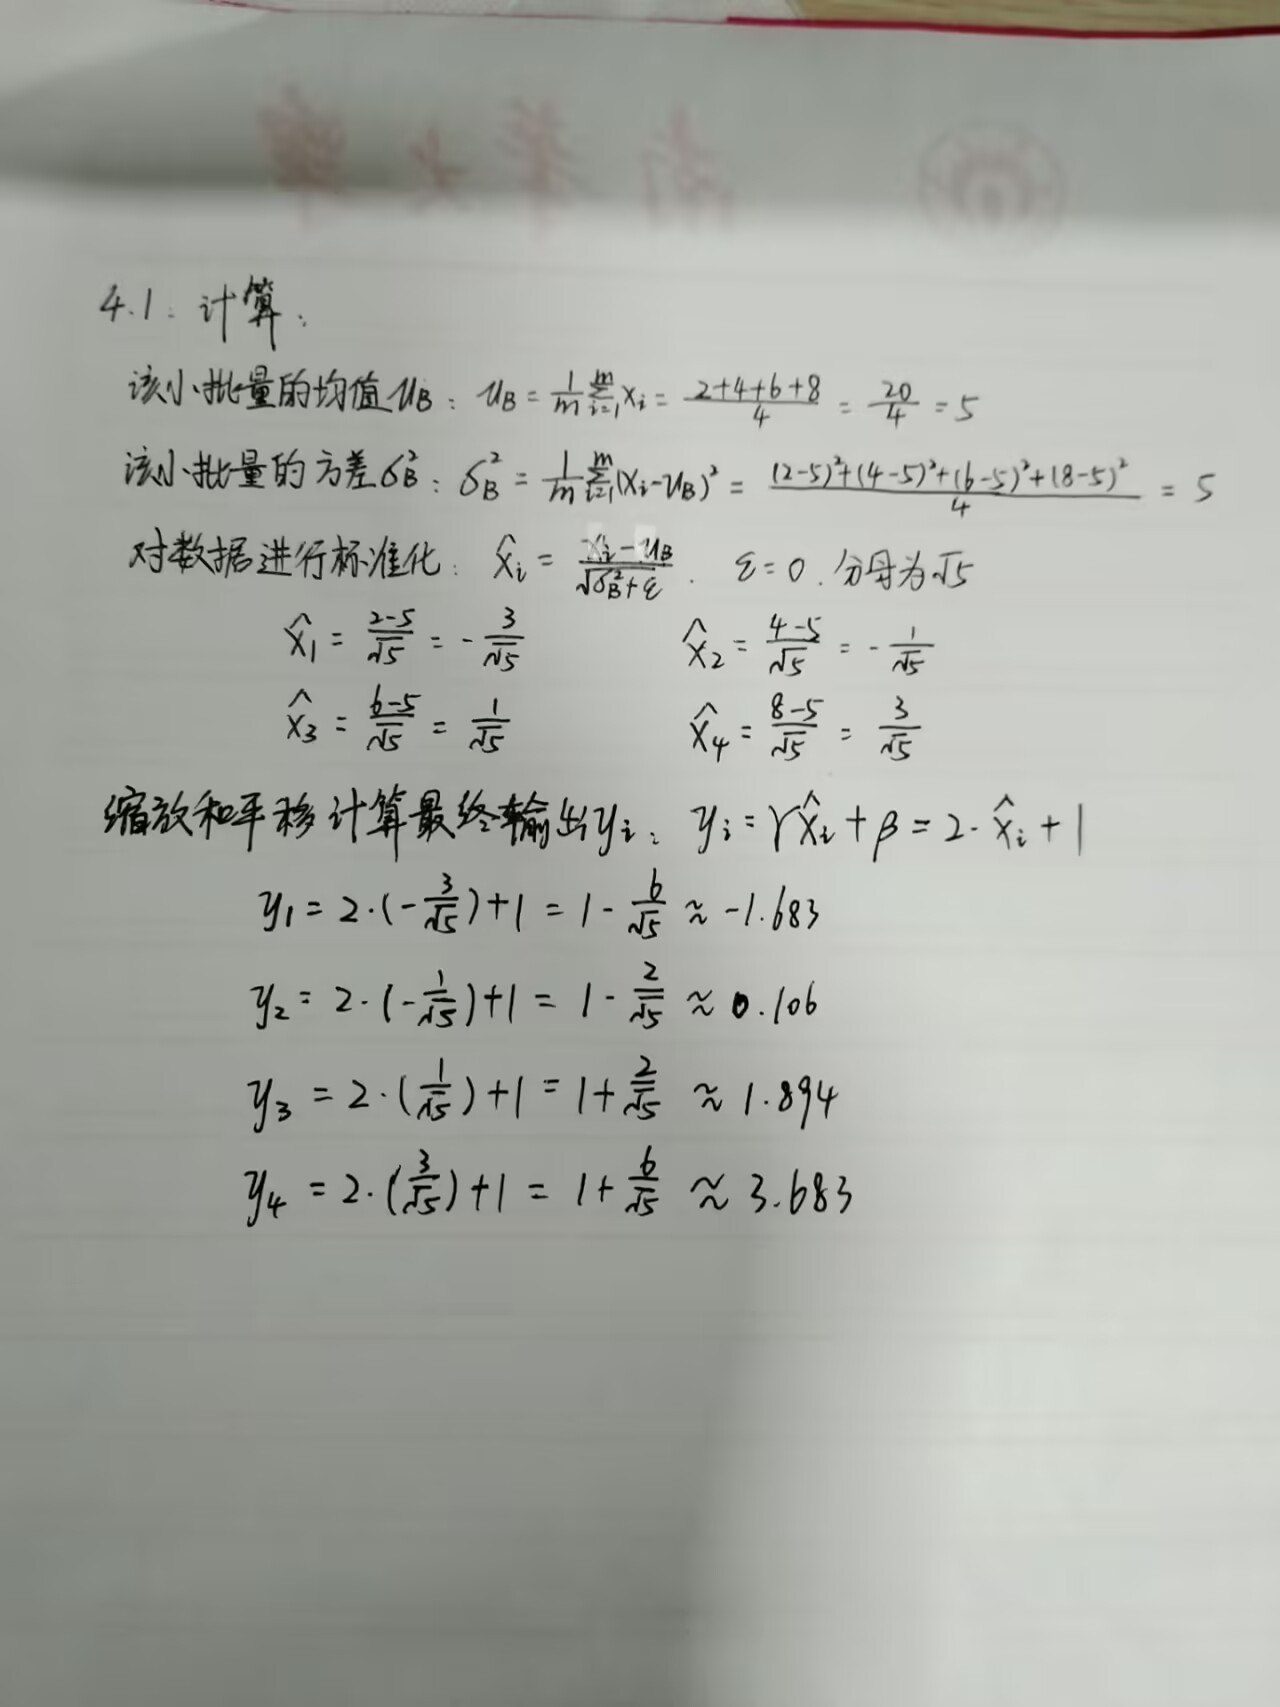

In [3]:
import torch
from torch import nn
from torch.nn import functional as F

class Residual(nn.Module):
    def __init__(self, input_channels, num_channels, use_1x1conv=False, strides=1):
        """
        定义残差块
        :param input_channels: 输入特征图的通道数
        :param num_channels:   输出特征图的通道数 (即该块内部卷积层的通道数)
        :param use_1x1conv:    布尔值，是否使用 1x1 卷积来调整输入的通道/尺寸
        :param strides:        第一层卷积的步幅，用于控制空间尺寸的缩放
        """
        super().__init__()
        
        # 1. 第一个 3x3 卷积层 (可能包含步幅以减小空间尺寸)
        # padding=1 保证了当 stride=1 时，输出的空间尺寸与输入一致
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.bn1 = nn.BatchNorm2d(num_channels)
        
        # 2. 第二个 3x3 卷积层 (步幅必须为 1，保持特征图尺寸与 conv1 输出一致)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(num_channels)
        
        # 3. 根据 use_1x1conv 决定是否添加跨层连接的 1x1 卷积
        if use_1x1conv:
            # 1x1 卷积，调整通道数到 num_channels，并应用相同的 strides 调整空间尺寸
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None

    def forward(self, X):
        # 主干路径 F(X)
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        
        # 跨层连接分支 X
        if self.conv3:
            X = self.conv3(X) # 调整 X 的形状以匹配 Y
            
        # 按元素相加: F(X) + X
        Y += X
        
        # 在相加之后再应用最后一次 ReLU 激活函数 (ResNet 的标准设计)
        return F.relu(Y)

# ==========================================
# 测试与验证代码
# ==========================================
if __name__ == "__main__":
    # 模拟一个输入张量 (Batch=4, Channels=3, Height=32, Width=32)
    X = torch.rand(4, 3, 32, 32)
    
    # 场景 1: 输入和输出形状一致，不需要 1x1 卷积
    blk_normal = Residual(input_channels=3, num_channels=3, use_1x1conv=False)
    out_normal = blk_normal(X)
    print(f"场景1 (不改变形状) 输入尺寸: {X.shape}")
    print(f"场景1 (不改变形状) 输出尺寸: {out_normal.shape}\n")
    
    # 场景 2: 通道数加倍(3->6)，且宽高减半(stride=2)，必须使用 1x1 卷积匹配形状
    blk_downsample = Residual(input_channels=3, num_channels=6, use_1x1conv=True, strides=2)
    out_downsample = blk_downsample(X)
    print(f"场景2 (通道增加+下采样) 输入尺寸: {X.shape}")
    print(f"场景2 (通道增加+下采样) 输出尺寸: {out_downsample.shape}")

场景1 (不改变形状) 输入尺寸: torch.Size([4, 3, 32, 32])
场景1 (不改变形状) 输出尺寸: torch.Size([4, 3, 32, 32])

场景2 (通道增加+下采样) 输入尺寸: torch.Size([4, 3, 32, 32])
场景2 (通道增加+下采样) 输出尺寸: torch.Size([4, 6, 16, 16])


5 图像增广，微调和样式迁移

1. 为什么对“底层特征提取层”设置较小学习率，对“顶层输出层”设置较大学习率？
答： 这主要是由深度神经网络分层提取特征的物理意义所决定的：
底层特征提取层（预训练层）： 这些层在庞大的源数据集（如 ImageNet）上已经学习到了极其强大且通用的底层视觉特征（例如：边缘、角点、基础纹理、色彩梯度等）。这些特征对于绝大多数视觉任务都是通用的。因此，我们只需要设置一个很小的学习率对其进行微小调整（微调），以适应新数据的微小分布差异；如果不小心使用了大学习率，反而会“洗掉”或破坏这些好不容易学到的宝贵特征。
顶层输出层（新初始化层）： 这一层是针对我们的新任务全新添加的（通常是随机初始化的分类器头）。它的参数完全是随机的垃圾值，尚未学习到任何有用信息。因此，我们需要给它一个较大的学习率，让它能够迅速基于底层传来的优质特征学习并收敛，快速建立特征到新标签的映射关系。
2. 目标数据集非常小，且与源数据集非常相似，应采取怎样的微调策略防过拟合？
答： 在这种情况下，模型极其容易死记硬背那为数不多的几个样本。应采取的策略是：
冻结绝大部分预训练层（Freezing）： 我们应该冻结整个网络几乎所有的“特征提取层”（将它们的 requires_grad 设为 False）。因为源数据集和目标数据集极其相似，预训练模型提取的特征已经近乎完美地适用于我们的任务，不需要任何修改。
仅训练顶层分类器（Linear Probing）： 我们只对最后新添加的用于输出结果的**线性分类层（分类器头）**进行训练。通过把绝大部分参数锁死，我们将原本极其庞大、容易过拟合的模型，退化成了一个简单的线性模型，从而从根本上消除了在小数据集上发生过拟合的风险。

In [4]:
import torch
import torchvision.transforms as transforms
from PIL import Image

def create_augmentation_pipeline():
    """
    创建一个组合图像增广管道 (Pipeline)
    """
    # Compose 用于将多个 transform 组合在一起，按照列表顺序依次执行
    train_augs = transforms.Compose([
        # 1. 随机对图像进行裁剪，面积比例 0.08 到 1.0，并缩放到 224 x 224
        transforms.RandomResizedCrop(
            size=(224, 224), 
            scale=(0.08, 1.0),
            ratio=(3.0/4.0, 4.0/3.0) # torchvision 的默认宽高比，通常一并加上
        ),
        
        # 2. 拥有 50% 的概率对图像进行水平翻转 (p=0.5 是默认值)
        transforms.RandomHorizontalFlip(p=0.5),
        
        # 3. 随机改变图像的亮度、对比度和饱和度，变化范围设为 0.5
        # (这三个参数的 0.5 意味着在 [1-0.5, 1+0.5] 即 [0.5, 1.5] 倍之间随机变动)
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
        
        # 4. 最终将 PIL 图像转换为 PyTorch 张量 (Tensor)，并将像素值缩放到 [0.0, 1.0]
        transforms.ToTensor()
    ])
    
    return train_augs

# ==========================================
# 演示代码：生成一张全黑图像测试 Pipeline 是否正常工作
# ==========================================
if __name__ == "__main__":
    # 创建 Pipeline
    pipeline = create_augmentation_pipeline()
    
    # 创建一张尺寸为 500x500 的纯红色 PIL 图像用于测试
    # 纯色图虽然看不出翻转效果，但可以清晰测试裁剪和色彩抖动以及张量转换
    img_test = Image.new('RGB', (500, 500), color='red')
    
    # 将测试图像传入增广管道
    img_transformed = pipeline(img_test)
    
    # 打印转换后的信息
    print("------- 图像增广测试 -------")
    print(f"原始图像尺寸 (PIL): {img_test.size}")
    print(f"增广后图像类型: {type(img_transformed)}")
    print(f"增广后图像张量尺寸 (C, H, W): {img_transformed.shape}")
    print(f"由于色彩抖动，增广后的张量数据不再是纯红(1.0, 0, 0)，而是产生了随机偏移：")
    print(f"R通道均值: {img_transformed[0].mean().item():.3f}")
    print(f"G通道均值: {img_transformed[1].mean().item():.3f}")
    print(f"B通道均值: {img_transformed[2].mean().item():.3f}")

------- 图像增广测试 -------
原始图像尺寸 (PIL): (500, 500)
增广后图像类型: <class 'torch.Tensor'>
增广后图像张量尺寸 (C, H, W): torch.Size([3, 224, 224])
由于色彩抖动，增广后的张量数据不再是纯红(1.0, 0, 0)，而是产生了随机偏移：
R通道均值: 0.514
G通道均值: 0.090
B通道均值: 0.090


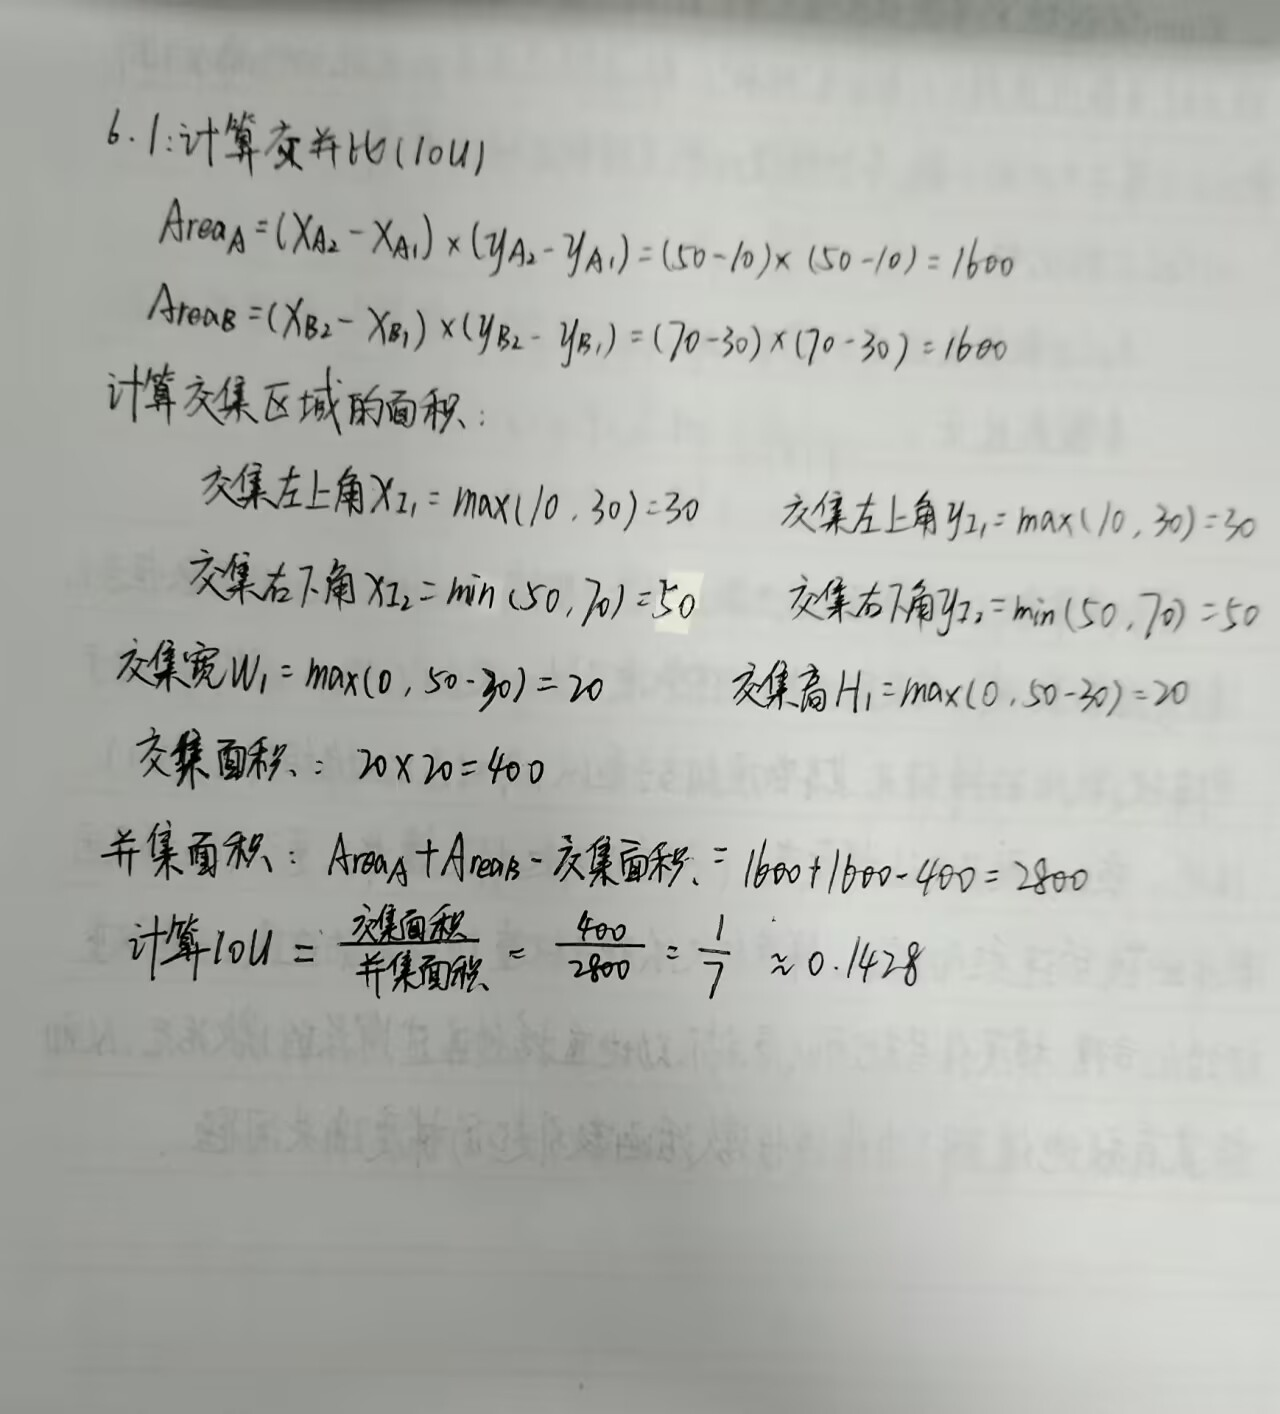

In [5]:
import torch
import torch.nn.functional as F

def label_smoothing_cross_entropy(preds, targets, epsilon=0.1):
    """
    计算带有标签平滑的交叉熵损失
    
    参数:
    - preds: 模型输出的未归一化逻辑值 (logits)，形状为 [batch_size, num_classes]
    - targets: 真实的类别索引，形状为 [batch_size]
    - epsilon: 平滑因子，默认为 0.1
    
    返回:
    - loss: 标量，该批次的平均损失
    """
    # 获取类别总数 K
    num_classes = preds.size(-1)
    
    # 1. 计算模型预测的对数概率 (Log Softmax)
    # 相比于先 softmax 再 log，直接使用 log_softmax 在数值计算上极其稳定，防止溢出或下溢
    log_preds = F.log_softmax(preds, dim=-1)
    
    # 2. 构造平滑后的真实标签矩阵 (Smoothed Target Distribution)
    # 首先创建一个全为 ε/(K-1) 的矩阵，形状与 preds 一致
    smooth_val = epsilon / (num_classes - 1)
    smoothed_targets = torch.full_like(preds, smooth_val)
    
    # 3. 将真实类别对应位置的概率值替换为 (1 - ε)
    # 使用 scatter_ 方法沿着 dim=1 将 (1 - epsilon) 填入 targets 所在的索引位置
    smoothed_targets.scatter_(dim=1, index=targets.unsqueeze(1), value=1.0 - epsilon)
    
    # 4. 计算最终的交叉熵损失: Loss = - sum(smoothed_target * log_prob)
    # 沿着类别维度 (dim=-1) 求和，然后在整个批次上求平均 (mean)
    loss = (-smoothed_targets * log_preds).sum(dim=-1).mean()
    
    return loss

# ==========================================
# 测试与验证代码
# ==========================================
if __name__ == "__main__":
    # 模拟数据: Batch Size = 2, 分类数 K = 5
    batch_size = 2
    num_classes = 5
    
    # 模型预测输出 (未经 softmax 的 logits)
    logits = torch.tensor([[2.0, 0.5, 0.1, -1.0, 1.5],
                           [0.1, 3.0, 0.2, 0.5, -0.5]])
    
    # 真实标签索引
    targets = torch.tensor([0, 1]) # 样本1属于类别0，样本2属于类别1
    
    # 1. 计算普通交叉熵损失
    loss_normal = F.cross_entropy(logits, targets)
    
    # 2. 计算标签平滑交叉熵损失 (ε = 0.1)
    loss_smoothed = label_smoothing_cross_entropy(logits, targets, epsilon=0.1)
    
    print(f"普通交叉熵损失 (One-Hot): {loss_normal.item():.4f}")
    print(f"标签平滑交叉熵损失 (ε=0.1): {loss_smoothed.item():.4f}")
    
    # --- 深入验证：打印平滑后的标签矩阵看看长什么样 ---
    smooth_val = 0.1 / (5 - 1)
    print(f"\n[验证] 平滑因子的分配：")
    print(f"真实类应得概率: 1 - 0.1 = 0.9000")
    print(f"错误类应得概率: 0.1 / 4 = {smooth_val:.4f}")

普通交叉熵损失 (One-Hot): 0.4565
标签平滑交叉熵损失 (ε=0.1): 0.6890

[验证] 平滑因子的分配：
真实类应得概率: 1 - 0.1 = 0.9000
错误类应得概率: 0.1 / 4 = 0.0250
